<a href="https://colab.research.google.com/github/Lanaanvar/Deep-Learning/blob/main/Metrics_and_Stress_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

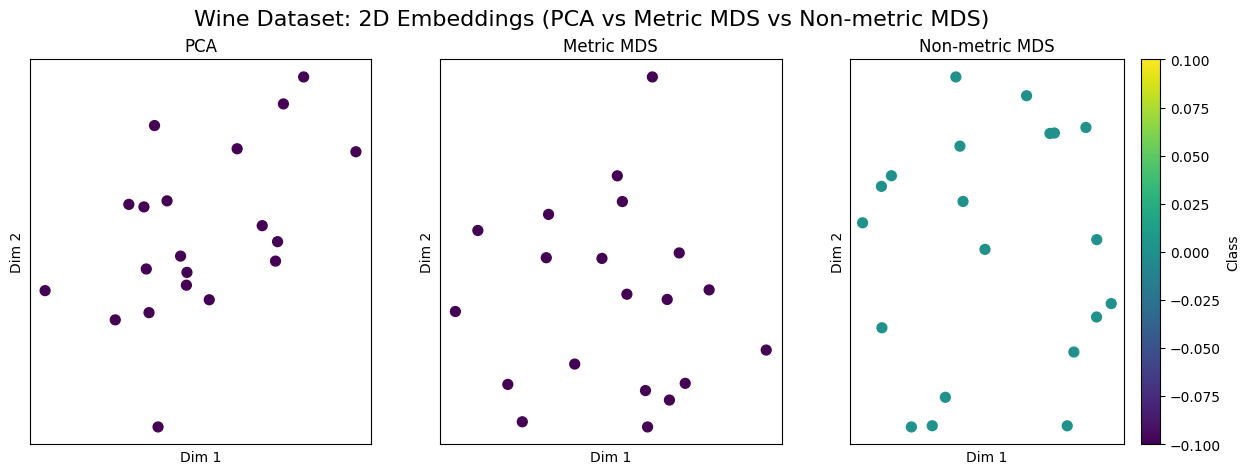

In [1]:
# --- PCA vs Metric MDS vs Non-metric MDS on Wine Dataset ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler

# Load Wine dataset
wine = load_wine()
X = wine.data
y = wine.target

# Standardize data
X_scaled = StandardScaler().fit_transform(X)

# Define methods
pca = PCA(n_components=2, random_state=42)
mds_metric = MDS(n_components=2, metric=True, random_state=42)
mds_nonmetric = MDS(n_components=2, metric=False, random_state=42, n_init=4, max_iter=300)

# Fit and transform
X_pca = pca.fit_transform(X_scaled)
X_mds_metric = mds_metric.fit_transform(X_scaled)
X_mds_nonmetric = mds_nonmetric.fit_transform(X_scaled)

# Plotting the first 20 embeddings
plt.figure(figsize=(15, 5))
methods = [("PCA", X_pca), ("Metric MDS", X_mds_metric), ("Non-metric MDS", X_mds_nonmetric)]

for i, (name, emb) in enumerate(methods):
    plt.subplot(1, 3, i + 1)
    scatter = plt.scatter(emb[:20, 0], emb[:20, 1], c=y[:20], cmap='viridis', s=50)
    plt.title(name)
    plt.xlabel('Dim 1'); plt.ylabel('Dim 2')
    plt.xticks([]); plt.yticks([])

plt.suptitle("Wine Dataset: 2D Embeddings (PCA vs Metric MDS vs Non-metric MDS)", fontsize=16)
plt.colorbar(scatter, ax=plt.gca(), label="Class")
plt.show()


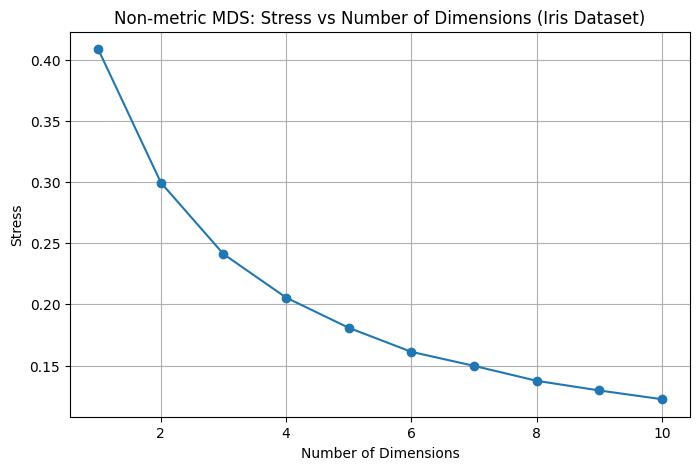

In [2]:
# --- Stress vs Dimensions for Non-metric MDS on Iris ---
from sklearn.datasets import load_iris
from sklearn.manifold import MDS

iris = load_iris()
X_iris = iris.data
X_iris_scaled = StandardScaler().fit_transform(X_iris)

dims = range(1, 11)
stress_values = []

for d in dims:
    mds_nonmetric = MDS(n_components=d, metric=False, random_state=42, n_init=4, max_iter=300)
    mds_nonmetric.fit(X_iris_scaled)
    stress_values.append(mds_nonmetric.stress_)

plt.figure(figsize=(8, 5))
plt.plot(dims, stress_values, marker='o')
plt.title("Non-metric MDS: Stress vs Number of Dimensions (Iris Dataset)")
plt.xlabel("Number of Dimensions")
plt.ylabel("Stress")
plt.grid(True)
plt.show()
